# Heavy Equipment Selling Price Prediction

**Machine Learning Project**

> **Name:** Anas Khan  
> **Roll No:** 24f100851

## Objective

> The goal of this project is to build a machine learning model that predicts the **selling price of heavy equipment** based on the available equipment and sale-related information.

> Each record contains:
> - **Equipment details** such as model and product information
> - **Machine characteristics** and specifications
> - **Sale-related information** such as sale date and sale type
> - **Usage and equipment attributes** that may influence the selling price

The problem is a **supervised regression task**.

## 1. Importing Libraries

Libraries required for data handling, visualization, preprocessing, feature engineering, model building, cross-validation, and evaluation.

- **Data Handling:** NumPy, Pandas
- **Visualization:** Matplotlib, Seaborn
- **Preprocessing:** SimpleImputer, LabelEncoder, OneHotEncoder, StandardScaler
- **Pipeline:** ColumnTransformer, Pipeline
- **Model Selection:** train_test_split, KFold, RandomizedSearchCV
- **Models:** Ridge, ElasticNet, Extra Trees Regressor, XGBoost, LightGBM, CatBoost
- **Evaluation:** Mean Squared Logarithmic Error
- **Utilities:** os, re, gc, warnings

In [1]:
import os
import re
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
import xgboost as xgb

from catboost import CatBoostRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_log_error


def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, np.clip(y_pred, 1, None)))

warnings.filterwarnings("ignore")

SEED = 42
N_FOLDS = 5
N_SEEDS = 1
SEED_LIST = [SEED + i * 17 for i in range(N_SEEDS)]

np.random.seed(SEED)

## 2. Dataset Loading

In this step, the dataset files are loaded into Pandas DataFrames.

The dataset contains three files:

- **train.csv** – training data containing equipment information and the target variable `TargetValue`
- **test.csv** – test data containing equipment information without the target variable
- **sample_submission.csv** – sample submission file showing the required prediction format

The training and test datasets are loaded into `train_raw` and `test_raw` for further analysis and modeling. The sample submission file will be used later while preparing the final submission.

In [2]:
KAGGLE_DIR = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"
LOCAL_DIR = "/mnt/user-data/uploads"

DATA_DIR = KAGGLE_DIR if os.path.exists(KAGGLE_DIR) else LOCAL_DIR

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

train_raw = pd.read_csv(TRAIN_PATH, low_memory=False)
test_raw = pd.read_csv(TEST_PATH, low_memory=False)

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)

Train shape: (138701, 50)
Test shape: (15000, 49)


## Dataset Overview

After loading the dataset, we examine its basic structure to understand
the number of records, feature names, and data types.

This step helps identify different feature types and understand how
the data should be processed in later stages of the machine learning pipeline.

In [3]:
train_raw.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [4]:
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

## Feature Types

The dataset contains a combination of numerical, categorical, date, and identifier features.

### Numerical Features
- ManufactureYear
- OperationalHoursMeter
- ProductConfigID

### Categorical Features
- DataOriginCode
- VendorPartnerID
- UtilizationTier
- Spec_FullDescriptor
- Spec_BaseClass
- Spec_SubClass
- Spec_ReleaseSeries
- Spec_VariantModifier
- AssetScaleFactor
- FunctionalClassification
- RegionCode
- InventoryGroupCategory
- InventoryGroupDescription
- CabinType
- Forks
- DrivetrainType
- col1, col3–col16, col18–col25, col27–col30

### Date Feature
- TransactionDate

### Identifier Features
- TransactionID
- AssetID

### Target Variable
- TargetValue

Understanding the feature types helps determine the appropriate preprocessing and feature engineering techniques for different variables before model training.

In [5]:
train_raw.dtypes

TransactionID                  int64
TargetValue                  float64
AssetID                        int64
ProductConfigID                int64
DataOriginCode                object
VendorPartnerID               object
ManufactureYear                int64
OperationalHoursMeter        float64
UtilizationTier               object
TransactionDate               object
Spec_FullDescriptor           object
Spec_BaseClass                object
Spec_SubClass                 object
Spec_ReleaseSeries            object
Spec_VariantModifier          object
AssetScaleFactor              object
FunctionalClassification      object
RegionCode                    object
InventoryGroupCategory        object
InventoryGroupDescription     object
col1                          object
CabinType                     object
Forks                         object
col3                          object
col4                          object
DrivetrainType                object
col5                          object
c

## Missing Value Analysis

Before performing data preprocessing, it is important to check whether the dataset contains missing values.

Missing values can negatively affect machine learning models and may need to be handled through appropriate imputation methods.

In this dataset, we check each feature to identify the presence of missing values.

In [6]:
train_raw.isnull().sum()

TransactionID                     0
TargetValue                       0
AssetID                           0
ProductConfigID                   0
DataOriginCode                    0
VendorPartnerID                   0
ManufactureYear                   0
OperationalHoursMeter         56643
UtilizationTier               88226
TransactionDate                   0
Spec_FullDescriptor               0
Spec_BaseClass                    0
Spec_SubClass                 36985
Spec_ReleaseSeries           105805
Spec_VariantModifier          86369
AssetScaleFactor              41210
FunctionalClassification          0
RegionCode                        0
InventoryGroupCategory            0
InventoryGroupDescription         0
col1                         104915
CabinType                         0
Forks                        109382
col3                         109448
col4                         128320
DrivetrainType                89956
col5                         128320
col6                        

## Basic Statistics

This satisfies:

> “Visualizing key statistics”

In [7]:
train_raw.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


## Handling Missing Values

The dataset contains missing values in both numerical and categorical features.

- **Numerical features** will use median imputation, which is less sensitive to extreme values.
- **Categorical features** will use a separate `"Missing"` category to represent unavailable information.
- Features with high missingness are retained because they may still contain useful predictive information.

The imputation strategies are defined here and will be applied later through the preprocessing pipeline to ensure consistent handling of training and test data.

In [8]:
missing_cols = train_raw.columns[train_raw.isnull().any()]

numeric_missing_cols = (train_raw[missing_cols].select_dtypes(include="number").columns.tolist())

categorical_missing_cols = (train_raw[missing_cols].select_dtypes(include="object").columns.tolist())

numeric_imputer = SimpleImputer(strategy="median")

categorical_imputer = SimpleImputer(strategy="constant",fill_value="Missing")

print("Numerical columns with missing values:")
print(numeric_missing_cols)

print("\nCategorical columns with missing values:")
print(categorical_missing_cols)

Numerical columns with missing values:
['OperationalHoursMeter']

Categorical columns with missing values:
['UtilizationTier', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'col1', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


## 3. Baseline Model - Dummy Regressor

A **Dummy Regressor** is used to establish a simple baseline performance.

This gives us a reference score that can later be compared with the machine learning models to check whether they are learning useful patterns from the data.

In [9]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_log_error

X = train_raw.drop(columns="TargetValue")
y = train_raw["TargetValue"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21
)

dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_val)

dummy_rmsle = root_mean_squared_log_error(y_val, dummy_pred)

print(f"Dummy Regressor RMSLE: {dummy_rmsle:.5f}")

Dummy Regressor RMSLE: 0.67194


**Observation:**  
The Dummy Regressor provides a baseline RMSLE score without learning relationships between the input features and the target.

The performance of the machine learning models developed later will be compared against this baseline.

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the dataset, identify data quality issues, and study the relationships between important features and the selling price.

The insights from this analysis will guide the preprocessing and feature engineering steps used later.

In [10]:
train_raw["TransactionDate"] = pd.to_datetime(train_raw["TransactionDate"],errors="coerce")

### 4.1 Target Distribution

**Why this plot?**

To understand how the selling price is distributed and check whether the target variable is skewed.

Since the evaluation metric is RMSLE, examining the log-transformed target also helps determine whether modeling the target in log space is appropriate.

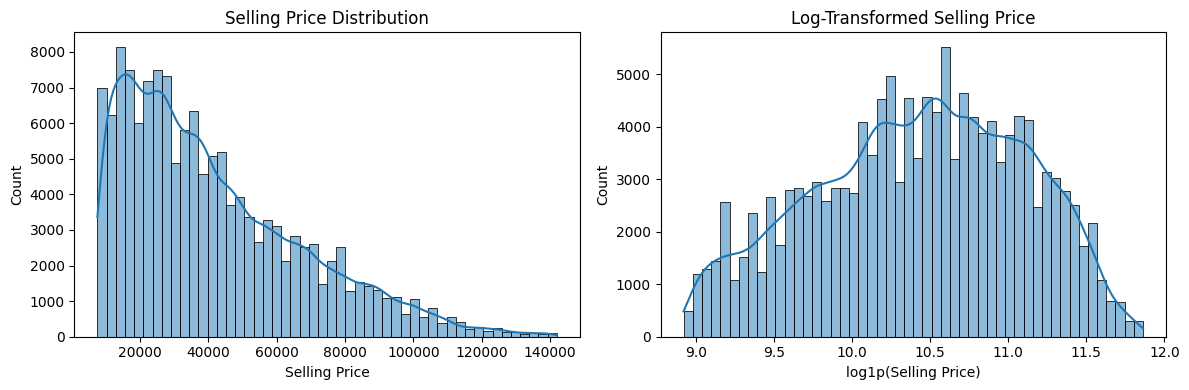

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    train_raw["TargetValue"],
    bins=50,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Selling Price Distribution")
axes[0].set_xlabel("Selling Price")
axes[0].set_ylabel("Count")

sns.histplot(
    np.log1p(train_raw["TargetValue"]),
    bins=50,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Log-Transformed Selling Price")
axes[1].set_xlabel("log1p(Selling Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Observation:**

The original selling price distribution is right-skewed, with a smaller number of high-priced equipment sales.

After applying `log1p`, the target distribution becomes more balanced. This suggests that training the models on the log-transformed target may help handle the skewness and is also suitable for RMSLE-based evaluation.

### 4.2 Missing Value Analysis

**Why this plot?**

To identify which features contain missing values and understand the extent of missing data in the dataset.

This helps determine where missing-value handling will be required during preprocessing.

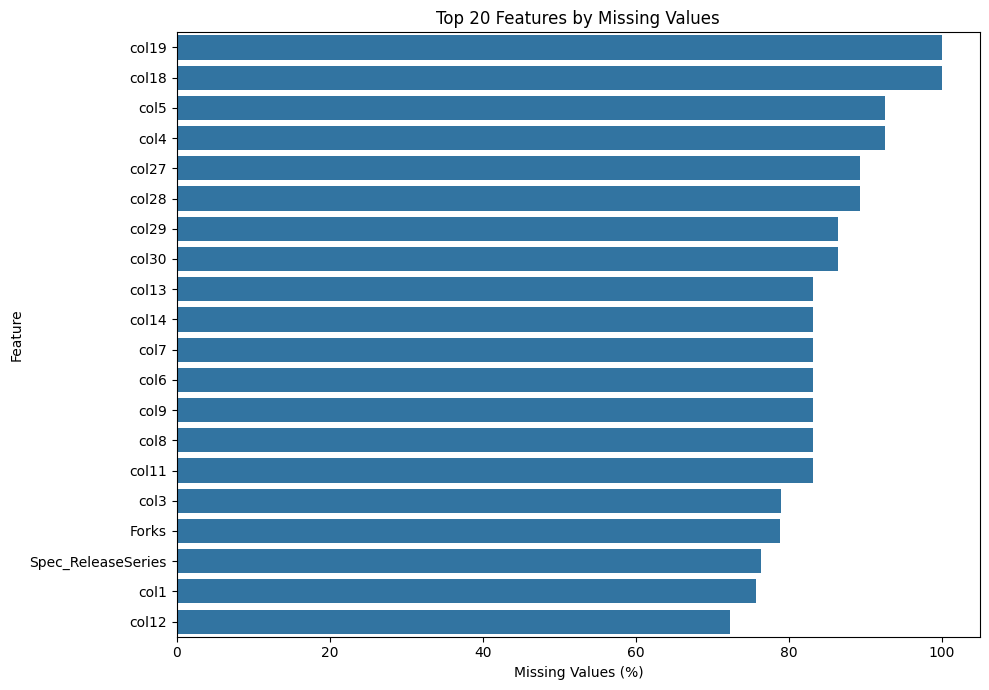

In [12]:
missing_pct = (
    train_raw.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_pct = missing_pct[missing_pct > 0].head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=missing_pct.values,
    y=missing_pct.index
)

plt.title("Top 20 Features by Missing Values")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Observation:**

Several features contain missing values, and the amount of missing data varies considerably across features.

Therefore, missing values need to be handled systematically during preprocessing. Numerical and categorical features may require different strategies depending on their data type and meaning.

### 4.3 Outlier Analysis

**Why this plot?**

To examine the spread of selling prices and identify the presence of unusually high or low target values.

Understanding extreme values is important because they can influence model training and prediction errors.

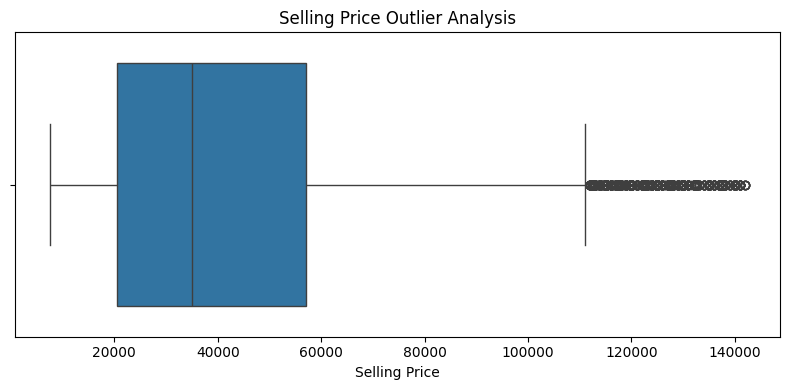

In [13]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=train_raw["TargetValue"])

plt.title("Selling Price Outlier Analysis")
plt.xlabel("Selling Price")
plt.tight_layout()
plt.show()

**Observation:**

The selling price contains several values beyond the upper whisker, indicating the presence of high-priced equipment compared with the majority of observations.

These values are not automatically removed because expensive equipment may represent valid transactions. Their effect will be considered during preprocessing and model building.

### 4.4 Numerical Correlations

**Why this plot?**

To understand the relationships between numerical features and the selling price, as well as relationships among the numerical features themselves.

This can help identify potentially useful predictors and strongly related features.

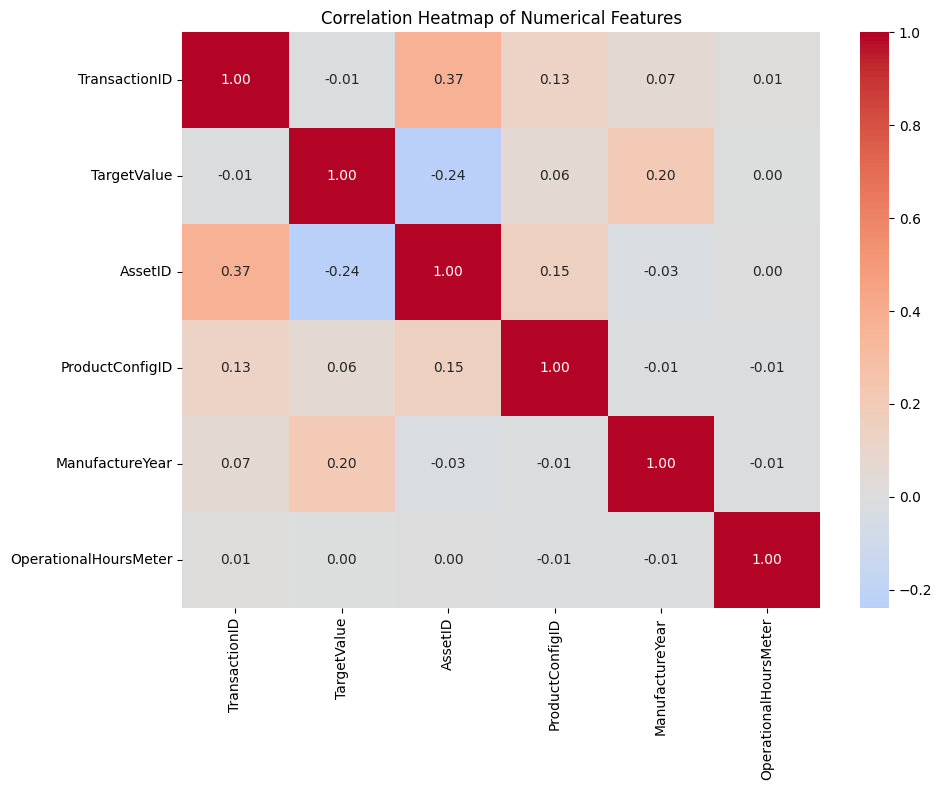

In [14]:
numeric_cols = train_raw.select_dtypes(include="number").columns
correlation = train_raw[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**Observation:**

The heatmap shows the strength and direction of linear relationships between the numerical features.

Some features show stronger relationships with the selling price than others, while correlations among input features can also reveal related information.

However, correlation only measures linear relationships, so features with low correlation may still be useful for non-linear machine learning models.

### 4.5 Equipment Age vs Selling Price

**Why this plot?**

To check whether the age of equipment at the time of sale has a relationship with its selling price.

Equipment age is calculated using the transaction year and manufacturing year.

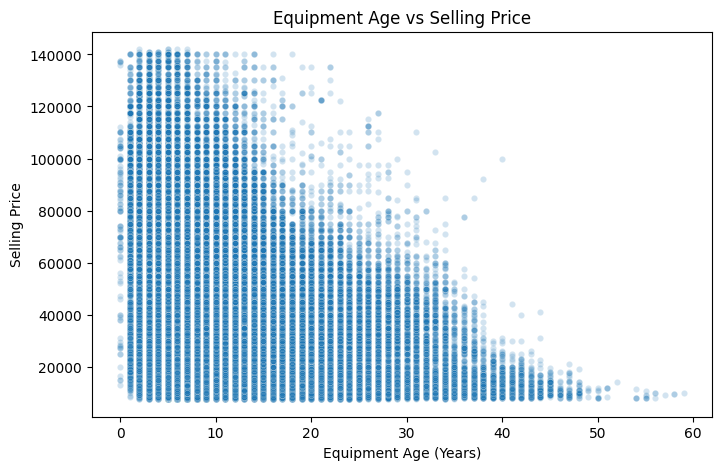

In [15]:
transaction_year = train_raw["TransactionDate"].dt.year
equipment_age = transaction_year - train_raw["ManufactureYear"]

valid_age = equipment_age.between(0, 60)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=equipment_age[valid_age],
    y=train_raw.loc[valid_age, "TargetValue"],
    alpha=0.2,
    s=20
)

plt.title("Equipment Age vs Selling Price")
plt.xlabel("Equipment Age (Years)")
plt.ylabel("Selling Price")
plt.show()

**Observation:**

The plot helps show how selling price changes with equipment age. The relationship suggests that age can provide useful information for predicting selling price.

This also motivates creating an **Equipment Age** feature during feature engineering instead of relying only on manufacturing year and transaction date separately.

### 4.6 Equipment Category vs Selling Price

**Why this plot?**

To check whether different categories of heavy equipment have different selling price ranges.

Only the eight most frequent categories are shown to keep the visualization clear and readable.

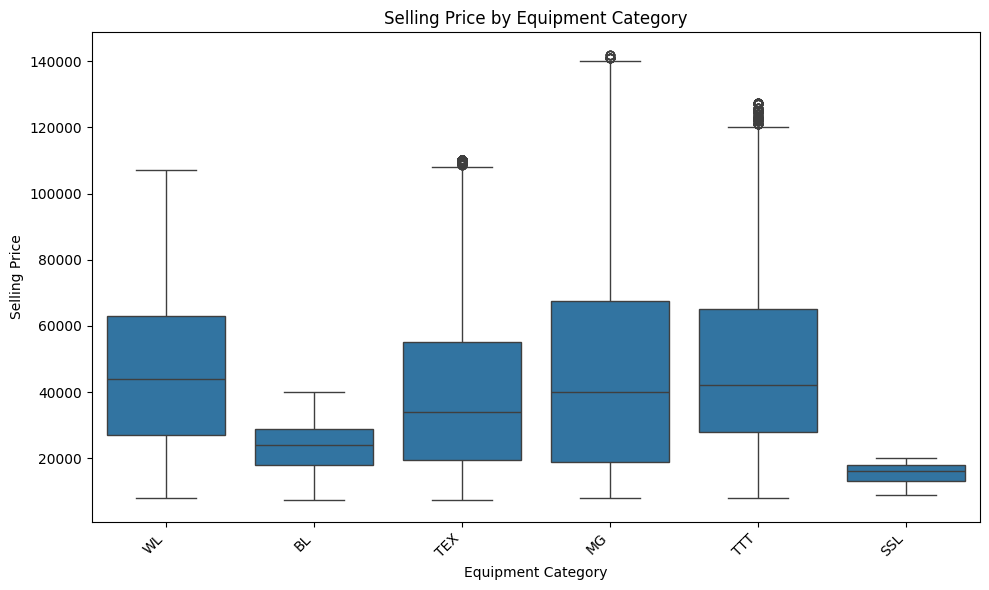

In [16]:
top_categories = (
    train_raw["InventoryGroupCategory"]
    .value_counts()
    .head(8)
    .index
)

category_data = train_raw[
    train_raw["InventoryGroupCategory"].isin(top_categories)
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=category_data,
    x="InventoryGroupCategory",
    y="TargetValue"
)

plt.title("Selling Price by Equipment Category")
plt.xlabel("Equipment Category")
plt.ylabel("Selling Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:**

The selling price distribution varies across equipment categories, indicating that the type of equipment contains useful information for price prediction.

Since this is a categorical feature, it will require appropriate encoding before it can be used by models that expect numerical input.

### 4.7 Selling Price Over Time

**Why this plot?**

To examine whether the average selling price changes over time.

If prices show a temporal pattern, information from the transaction date may be useful for predicting selling price.

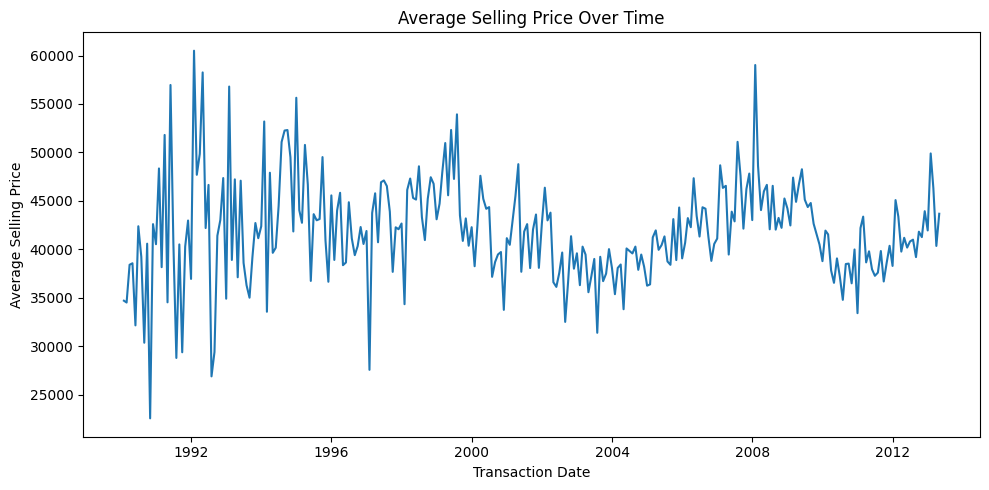

In [17]:
monthly_price = (
    train_raw.set_index("TransactionDate")["TargetValue"].resample("ME").mean())

plt.figure(figsize=(10, 5))

plt.plot(monthly_price.index, monthly_price.values)

plt.title("Average Selling Price Over Time")
plt.xlabel("Transaction Date")
plt.ylabel("Average Selling Price")
plt.tight_layout()
plt.show()

**Observation:**

The average selling price varies over time, suggesting that the time of sale may contain useful information for price prediction.

Therefore, components such as transaction year and month can be considered during feature engineering instead of using the raw date alone.

### 4.8 Operational Hours vs Selling Price

**Why this plot?**

To examine whether equipment usage, represented by operational hours, is related to the selling price.

A log scale is used for operational hours because the values cover a wide range.

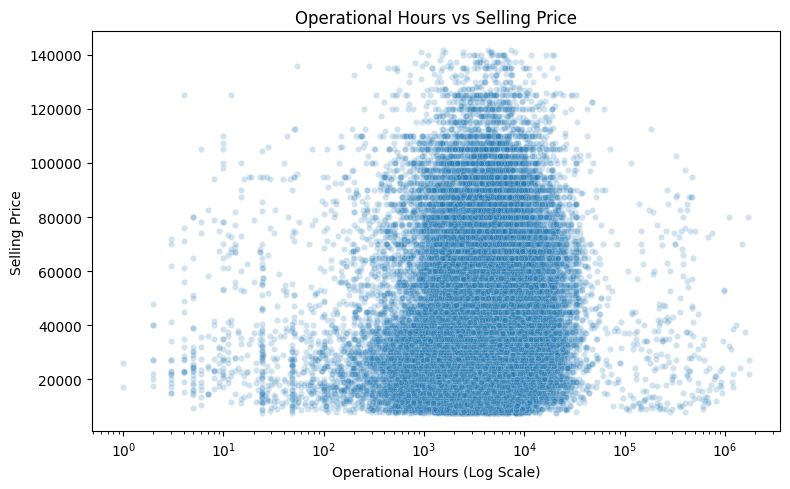

In [18]:
valid_hours = (
    train_raw["OperationalHoursMeter"].notna()
    & (train_raw["OperationalHoursMeter"] > 0)
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train_raw.loc[valid_hours],
    x="OperationalHoursMeter",
    y="TargetValue",
    alpha=0.2,
    s=20
)

plt.xscale("log")
plt.title("Operational Hours vs Selling Price")
plt.xlabel("Operational Hours (Log Scale)")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

**Observation:**

Operational hours show how much an equipment unit has been used before the transaction.

The plot helps determine whether usage level has a relationship with selling price. The wide range of operational-hour values also suggests that this feature may require careful handling during preprocessing and feature engineering.

### 4.9 Utilization Tier vs Selling Price

**Why this plot?**

To examine whether equipment with different levels of utilization has different selling price distributions.

This helps determine whether utilization level is a useful categorical feature for predicting selling price.

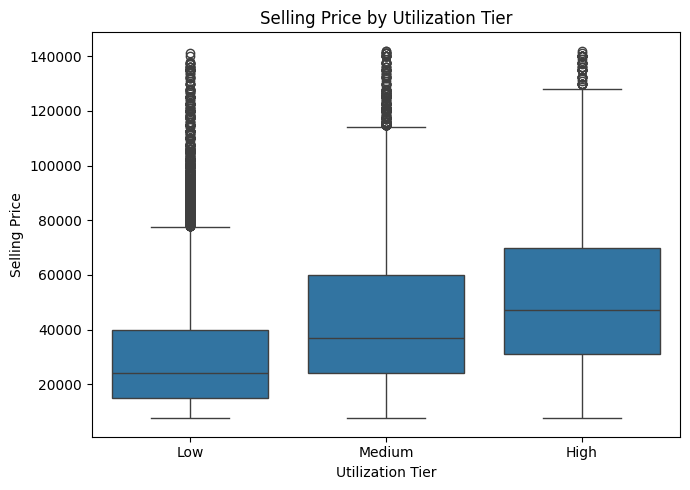

In [19]:
utilization_order = ["Low", "Medium", "High"]

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=train_raw,
    x="UtilizationTier",
    y="TargetValue",
    order=utilization_order
)

plt.title("Selling Price by Utilization Tier")
plt.xlabel("Utilization Tier")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.show()

**Observation:**

The selling price distribution differs across utilization levels, suggesting that equipment usage intensity may provide useful information for price prediction.

Since `UtilizationTier` is categorical, it will require appropriate handling during preprocessing before being used by models that require numerical input.

### 4.10 Cabin Type vs Selling Price

**Why this plot?**

To examine whether different cabin configurations have different selling price distributions.

Cabin type represents an equipment specification that may contribute to differences in equipment value.

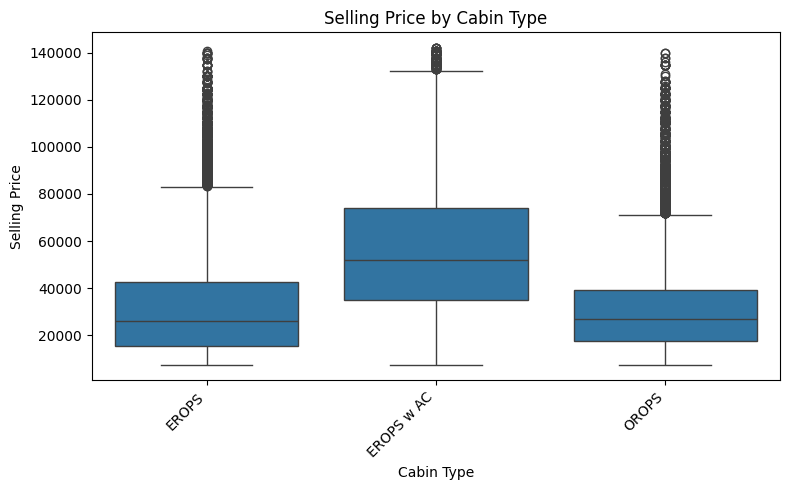

In [20]:
cabin_order = train_raw["CabinType"].value_counts().index

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train_raw,
    x="CabinType",
    y="TargetValue",
    order=cabin_order
)

plt.title("Selling Price by Cabin Type")
plt.xlabel("Cabin Type")
plt.ylabel("Selling Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:**

The selling price distribution varies across cabin types, indicating that cabin configuration may contain useful information for predicting equipment prices.

Since `CabinType` is categorical, it will require appropriate handling before being used by models that require numerical input.

## 5. Feature Engineering

Feature engineering transforms the original variables into more informative features that can improve the predictive performance of machine learning models.

The same feature engineering pipeline is applied to both the training and test datasets to ensure consistent transformations.

### 5.1 Parsing Helpers

Several equipment specification columns contain useful numerical information stored as text rather than numeric values.

The helper functions below extract structured numerical values such as dimensions, horsepower ranges, equipment weight, digging depth, and other measurements. These extracted values are later used to create meaningful numerical features during feature engineering.

In [21]:
def parse_feet_inches(value):
    """Convert values like 6' 3 into total inches."""
    
    if pd.isna(value) or str(value).strip() in ("", "None or Unspecified"):
        return np.nan

    match = re.match(r"(\d+)'\s*(\d+)?", str(value))

    if match:
        feet = int(match.group(1))
        inches = int(match.group(2)) if match.group(2) else 0
        return feet * 12 + inches

    return np.nan


def parse_inch_value(value):
    """Extract the leading numeric value from inch measurements."""
    
    if pd.isna(value) or str(value).strip() in ("", "None or Unspecified"):
        return np.nan

    match = re.match(
        r"([\d.]+)",
        str(value).replace('"', "").replace(" inch", "")
    )

    return float(match.group(1)) if match else np.nan


def parse_numeric_safe(value):
    """Safely extract the first numeric value from text."""
    
    if pd.isna(value) or str(value).strip() in ("", "None or Unspecified"):
        return np.nan

    match = re.match(r"([\d.]+)", str(value))

    return float(match.group(1)) if match else np.nan


def parse_hp_range(value):
    """Extract horsepower range."""
    
    if pd.isna(value):
        return np.nan, np.nan

    match = re.search(
        r"([\d.]+)\s+to\s+([\d.]+)\s+Horsepower",
        str(value)
    )

    if match:
        return float(match.group(1)), float(match.group(2))

    return np.nan, np.nan


def parse_metric_tons(value):
    """Extract metric ton range."""
    
    if pd.isna(value):
        return np.nan, np.nan

    match = re.search(
        r"([\d.]+)\s+to\s+([\d.]+)\s+Metric\s+Ton",
        str(value)
    )

    if match:
        return float(match.group(1)), float(match.group(2))

    return np.nan, np.nan


def parse_dig_depth(value):
    """Extract digging depth range in feet."""
    
    if pd.isna(value):
        return np.nan, np.nan

    match = re.search(
        r"([\d.]+)\s+to\s+([\d.]+)\s+Ft",
        str(value)
    )

    if match:
        return float(match.group(1)), float(match.group(2))

    return np.nan, np.nan

### 5.2 Feature Engineering Function

A reusable feature engineering function is created to transform the raw dataset into a richer feature set.

The function performs the following operations:

- Cleans placeholder values and removes highly sparse columns.
- Creates date-based and cyclical features.
- Derives equipment age and usage-related features.
- Extracts numerical information from specification fields.
- Converts selected categorical variables into ordinal and binary features.
- Creates interaction features between important variables.

The same function is applied to both the training and test datasets to ensure consistent feature generation.

In [22]:
def build_features(df):
    df = df.copy()

    df.drop(columns=["col18", "col19"], errors="ignore", inplace=True)

    object_columns = df.select_dtypes(include="object").columns

    for column in object_columns:
        df[column] = df[column].replace({
            "None or Unspecified": np.nan,
            "": np.nan
        })


    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

    df["TransactionYear"] = df["TransactionDate"].dt.year
    df["TransactionMonth"] = df["TransactionDate"].dt.month
    df["TransactionQuarter"] = df["TransactionDate"].dt.quarter
    df["TransactionDayOfWeek"] = df["TransactionDate"].dt.dayofweek
    df["TransactionDayOfYear"] = df["TransactionDate"].dt.dayofyear

    # Cyclical Encoding

    df["MonthSin"] = np.sin(
        2 * np.pi * df["TransactionMonth"] / 12
    )

    df["MonthCos"] = np.cos(
        2 * np.pi * df["TransactionMonth"] / 12
    )

    df["QuarterSin"] = np.sin(
        2 * np.pi * df["TransactionQuarter"] / 4
    )

    df["QuarterCos"] = np.cos(
        2 * np.pi * df["TransactionQuarter"] / 4
    )

    df["DowSin"] = np.sin(
        2 * np.pi * df["TransactionDayOfWeek"] / 7
    )

    df["DowCos"] = np.cos(
        2 * np.pi * df["TransactionDayOfWeek"] / 7
    )


    df["ManufactureYear"] = df["ManufactureYear"].clip(
        1950,
        2015
    )

    df["EquipmentAge"] = (
        df["TransactionYear"] - df["ManufactureYear"]
    ).clip(0, 60)

    df["AgeBucket"] = pd.cut(
        df["EquipmentAge"],
        bins=[-1, 2, 5, 10, 15, 20, 30, 60],
        labels=[
            "0-2",
            "3-5",
            "6-10",
            "11-15",
            "16-20",
            "21-30",
            "30+"
        ]
    )

    df["AgeSq"] = df["EquipmentAge"] ** 2
    df["LogAge"] = np.log1p(df["EquipmentAge"])
    df["InvAge"] = 1.0 / (df["EquipmentAge"] + 1)
    df["AgeCubeRoot"] = np.cbrt(df["EquipmentAge"])
    

    hours = df["OperationalHoursMeter"]

    df["LogHours"] = np.log1p(hours.fillna(0))

    df["HoursPerYear"] = (
        hours /
        df["EquipmentAge"].replace(0, 1)
    )

    df["LogHoursPerYear"] = np.log1p(df["HoursPerYear"])

    df["HoursMissing"] = hours.isna().astype(int)

    df["HoursSq"] = df["LogHours"] ** 2

    df["HoursClipped"] = (
        hours
        .clip(0, 50000)
        .fillna(0)
    )


    df["SpecBaseNum"] = (
        df["Spec_FullDescriptor"]
        .str.extract(r"(\d+)")
        .astype(float)
    )

    df["StickLengthIn"] = (
        df["col22"]
        .apply(parse_feet_inches)
    )

    df["TireSizeIn"] = (
        df["col15"]
        .apply(parse_inch_value)
    )

    df["TrackWidthIn"] = (
        df["col21"]
        .apply(parse_inch_value)
    )

    df["BucketWidthFt"] = (
        df["col7"]
        .apply(parse_inch_value)
    )

    df["RatedPowerNum"] = (
        df["col9"]
        .apply(parse_numeric_safe)
    )

    hp_data = (
        df["FunctionalClassification"]
        .apply(parse_hp_range)
    )

    ton_data = (
        df["FunctionalClassification"]
        .apply(parse_metric_tons)
    )

    depth_data = (
        df["FunctionalClassification"]
        .apply(parse_dig_depth)
    )

    df["HP_Low"] = hp_data.apply(lambda x: x[0])
    df["HP_High"] = hp_data.apply(lambda x: x[1])
    df["HP_Mid"] = (
        df["HP_Low"] +
        df["HP_High"]
    ) / 2

    df["Ton_Low"] = ton_data.apply(lambda x: x[0])
    df["Ton_High"] = ton_data.apply(lambda x: x[1])
    df["Ton_Mid"] = (
        df["Ton_Low"] +
        df["Ton_High"]
    ) / 2

    df["DigDepth_Low"] = depth_data.apply(lambda x: x[0])
    df["DigDepth_High"] = depth_data.apply(lambda x: x[1])
    df["DigDepth_Mid"] = (
        df["DigDepth_Low"] +
        df["DigDepth_High"]
    ) / 2

    df["EquipSizeMid"] = (
        df["HP_Mid"]
        .fillna(df["Ton_Mid"])
        .fillna(df["DigDepth_Mid"])
    )


    df["UtilizationOrdinal"] = df["UtilizationTier"].map({
        "Low": 0,
        "Medium": 1,
        "High": 2,
    })

    df["ScaleOrdinal"] = df["AssetScaleFactor"].map({
        "Mini": 0,
        "Compact": 1,
        "Small": 2,
        "Medium": 3,
        "Large / Medium": 4,
        "Large": 5,
    })

    df["HasAC"] = (df["CabinType"] == "EROPS w AC").astype(int)

    df["IsEROPS"] = (
        df["CabinType"]
        .isin(["EROPS", "EROPS w AC"])
        .astype(int)
    )

    df["IsORPS"] = (
        df["CabinType"] == "OROPS"
    ).astype(int)

    df["Is4WD"] = (
        df["col1"] == "Four Wheel Drive"
    ).astype(int)

    df["DriveOrdinal"] = df["DrivetrainType"].map({
        np.nan: 0,
        "Direct Drive": 1,
        "Hydrostatic": 2,
        "Powershuttle": 3,
        "Autoshift": 3,
        "AutoShift": 3,
        "Standard": 4,
        "Powershift": 5,
    }).fillna(0)


    age = df["EquipmentAge"]
    log_hours = df["LogHours"]
    scale = df["ScaleOrdinal"].fillna(0)
    utilization = df["UtilizationOrdinal"].fillna(0)
    hp = df["HP_Mid"].fillna(0)
    ton = df["Ton_Mid"].fillna(0)
    size = df["EquipSizeMid"].fillna(0)

    df["AgeXLogHours"] = age * log_hours
    df["YearsFromBoom"] = abs(df["TransactionYear"] - 2006)

    df["AgeXScale"] = age * scale
    df["AgeXHasAC"] = age * df["HasAC"]
    df["AgeXUtilization"] = age * utilization

    df["LogHoursXScale"] = log_hours * scale
    df["SpecBaseXScale"] = (
        df["SpecBaseNum"].fillna(0) * scale
    )

    df["YearXAge"] = df["TransactionYear"] * age
    df["HPxAge"] = hp * age
    df["TonXAge"] = ton * age

    df["AgeXLogHoursXScale"] = (
        age * log_hours * scale
    )

    df["SizeXAge"] = size * age
    df["SizeXLogHours"] = size * log_hours
    df["LogAgeXLogHours"] = (
        df["LogAge"] * log_hours
    )

    return df

### 5.3 Apply Feature Engineering

The feature engineering function is applied to both the training and test datasets to ensure that identical transformations are performed before model training and prediction.

In [23]:
print("Building engineered features")

train = build_features(train_raw)
test = build_features(test_raw)

print(f"Train shape after feature engineering: {train.shape}")
print(f"Test shape after feature engineering: {test.shape}")

Building engineered features
Train shape after feature engineering: (138701, 108)
Test shape after feature engineering: (15000, 107)


# 6. Advanced Feature Engineering

Additional features are created after the primary feature engineering stage to provide more useful information for the machine learning models.

This section focuses on:

- identifying missing-value patterns,
- capturing asset-level information,
- creating frequency-based categorical features,
- organizing the final feature lists used during model training.

These features are generated consistently for both the training and test datasets.

## 6.1 Missing Value Indicators

Missing values themselves may contain useful information. Instead of only imputing missing values, binary indicator features are created to identify whether a value was originally missing.

Indicator features are created only for columns with a reasonable proportion of missing values to avoid creating unnecessary features.

In [24]:
skip_missing = {
    "TransactionID",
    "TargetValue",
    "TransactionDate",
}

missing_indicator_cols = []

for column in train.columns:

    if column in skip_missing:
        continue

    missing_ratio = train[column].isna().mean()

    if 0.01 < missing_ratio < 0.99:

        indicator = f"miss_{column}"

        train[indicator] = train[column].isna().astype(np.int8)
        test[indicator] = test[column].isna().astype(np.int8)

        missing_indicator_cols.append(indicator)

print(f"Created {len(missing_indicator_cols)} missing-value indicator features")

Created 49 missing-value indicator features


## 6.2 Asset-Level Features

The resale history of an asset can provide useful information about its selling price.

Features are created to identify:

- how many times an asset appears in the training data,
- whether it is a repeat sale,
- a placeholder for the asset median price, which is calculated later using leak-free out-of-fold statistics.

In [25]:
asset_sale_counts = train_raw.groupby("AssetID").size()

train["AssetSaleCount"] = (train["AssetID"].map(asset_sale_counts).fillna(1))

test["AssetSaleCount"] = (test["AssetID"].map(asset_sale_counts).fillna(1))

train["AssetIsRepeatSale"] = (train["AssetSaleCount"] > 1).astype(np.int8)

test["AssetIsRepeatSale"] = (test["AssetSaleCount"] > 1).astype(np.int8)


train["AssetMedianPrice"] = np.nan
test["AssetMedianPrice"] = np.nan

## 6.3 Frequency Encoding

Many categorical variables contain categories that occur with very different frequencies.

Instead of using the raw category labels directly, frequency encoding replaces each category with the number of times it appears in the training dataset. This provides the model with information about how common or rare each category is while keeping the dimensionality low.

The frequency mappings are learned only from the training dataset and then applied consistently to both the training and test datasets.

In [26]:
CAT_COLS = [
    "DataOriginCode",
    "VendorPartnerID",
    "UtilizationTier",
    "Spec_BaseClass",
    "Spec_SubClass",
    "Spec_ReleaseSeries",
    "Spec_VariantModifier",
    "AssetScaleFactor",
    "FunctionalClassification",
    "RegionCode",
    "InventoryGroupCategory",
    "InventoryGroupDescription",
    "CabinType",
    "Forks",
    "DrivetrainType",
    "col1",
    "col3",
    "col4",
    "col5",
    "col6",
    "col7",
    "col8",
    "col9",
    "col10",
    "col11",
    "col12",
    "col13",
    "col14",
    "col15",
    "col16",
    "col20",
    "col21",
    "col22",
    "col23",
    "col24",
    "col25",
    "col27",
    "col28",
    "col29",
    "col30",
    "AgeBucket",
]

freq_cols = []

for column in CAT_COLS:

    freq_feature = f"Freq_{column}"

    frequency_map = train[column].value_counts(dropna=False)

    train[freq_feature] = (
        train[column]
        .map(frequency_map)
        .astype(object)
        .fillna(0)
        .astype(int)
    )

    test[freq_feature] = (
        test[column]
        .map(frequency_map)
        .astype(object)
        .fillna(0)
        .astype(int)
    )

    freq_cols.append(freq_feature)

print(f"Created {len(freq_cols)} frequency encoded features")

Created 41 frequency encoded features


## 6.4 Feature Configuration

The engineered dataset contains a mixture of numerical and categorical features.

To improve code readability and avoid repeatedly selecting columns throughout the notebook, the feature names are organized into reusable lists. These lists are later used during preprocessing, target encoding, model preparation, and training.

Maintaining centralized feature lists also makes the notebook easier to modify and reduces the likelihood of errors during experimentation.

In [27]:
NUM_COLS = [

    # Date Features
    "ManufactureYear",
    "OperationalHoursMeter",
    "TransactionYear",
    "TransactionMonth",
    "TransactionQuarter",
    "TransactionDayOfWeek",
    "TransactionDayOfYear",
    "MonthSin",
    "MonthCos",
    "QuarterSin",
    "QuarterCos",
    "DowSin",
    "DowCos",

    # Equipment Age Features
    "EquipmentAge",
    "AgeSq",
    "LogAge",
    "InvAge",
    "AgeCubeRoot",

    # Operational Hours Features
    "LogHours",
    "HoursPerYear",
    "LogHoursPerYear",
    "HoursMissing",
    "HoursSq",
    "HoursClipped",

    # Equipment Specification Features
    "SpecBaseNum",
    "StickLengthIn",
    "TireSizeIn",
    "TrackWidthIn",
    "BucketWidthFt",
    "RatedPowerNum",

    # Horsepower / Weight / Digging Depth
    "HP_Low",
    "HP_High",
    "HP_Mid",
    "Ton_Low",
    "Ton_High",
    "Ton_Mid",
    "DigDepth_Low",
    "DigDepth_High",
    "DigDepth_Mid",
    "EquipSizeMid",

    # Ordinal & Binary Features
    "UtilizationOrdinal",
    "ScaleOrdinal",
    "HasAC",
    "IsEROPS",
    "IsORPS",
    "Is4WD",
    "DriveOrdinal",
    "ProductConfigID",

    # Interaction Features
    "AgeXLogHours",
    "YearsFromBoom",
    "AgeXScale",
    "AgeXHasAC",
    "AgeXUtilization",
    "LogHoursXScale",
    "SpecBaseXScale",
    "YearXAge",
    "HPxAge",
    "TonXAge",
    "AgeXLogHoursXScale",
    "SizeXAge",
    "SizeXLogHours",
    "LogAgeXLogHours",

    # Asset Features
    "AssetSaleCount",
    "AssetIsRepeatSale",
    "AssetMedianPrice",

] + freq_cols + missing_indicator_cols

print(f"Numerical Features: {len(NUM_COLS)}")
print(f"Categorical Features: {len(CAT_COLS)}")

Numerical Features: 155
Categorical Features: 41


# 7. Data Preparation

After completing feature engineering, the dataset is prepared for model training.

This section separates the target variable from the input features and prepares independent training and test datasets. Organizing the data at this stage improves readability and makes the subsequent preprocessing and modeling steps more systematic.

In [28]:
# Target variable (log-transformed selling price)
y = np.log1p(train["TargetValue"])

print(f"Training samples : {len(train):,}")
print(f"Target variable  : TargetValue")

Training samples : 138,701
Target variable  : TargetValue


## 7.1 Separate Features and Target

The target variable is removed from the training dataset to create the input feature matrix.

The TransactionID is also excluded since it is only an identifier and does not contribute to predicting the selling price.

The same feature structure is maintained for the test dataset to ensure consistency during prediction.

In [29]:
DROP_COLS = ["TransactionID", "TargetValue"]

X_train = train.drop(columns=DROP_COLS)
X_test = test.drop(columns=["TransactionID"])

print(f"Training Feature Matrix : {X_train.shape}")
print(f"Test Feature Matrix     : {X_test.shape}")

Training Feature Matrix : (138701, 199)
Test Feature Matrix     : (15000, 199)


## 7.2 Verify Prepared Dataset

Before preprocessing, the prepared datasets are verified to ensure that:

- the target variable has been separated correctly,
- the feature dimensions are consistent,
- and the training and test datasets contain the same predictor variables.

This validation step helps detect structural issues before model training.

In [30]:
print(f"Number of Training Features : {X_train.shape[1]}")
print(f"Number of Test Features     : {X_test.shape[1]}")

assert list(X_train.columns) == list(X_test.columns), \
    "Train and Test columns do not match."

print("Feature columns verified successfully.")

Number of Training Features : 199
Number of Test Features     : 199
Feature columns verified successfully.


# 8. Feature Configuration

The engineered dataset contains both numerical and categorical variables.

Before applying preprocessing, the features are organized into separate groups based on their data types. This improves code readability and allows different preprocessing techniques to be applied to numerical and categorical features using a reusable preprocessing pipeline.

The feature lists defined in this section are reused throughout model training and evaluation.

In [31]:
numeric_features = NUM_COLS.copy()

categorical_features = CAT_COLS.copy()

print(f"Numerical Features   : {len(numeric_features)}")
print(f"Categorical Features : {len(categorical_features)}")
print(f"Total Features       : {len(numeric_features) + len(categorical_features)}")

Numerical Features   : 155
Categorical Features : 41
Total Features       : 196


## 8.1 Verify Feature Lists

Before preprocessing, the feature lists are validated to ensure that all selected columns are present in both the training and test datasets.

This helps identify missing or incorrectly named features before model training begins.

In [32]:
missing_train = [
    col for col in numeric_features + categorical_features
    if col not in X_train.columns
]

missing_test = [
    col for col in numeric_features + categorical_features
    if col not in X_test.columns
]

print(f"Missing in Train : {len(missing_train)}")
print(f"Missing in Test  : {len(missing_test)}")

assert len(missing_train) == 0, "Some features are missing in X_train."
assert len(missing_test) == 0, "Some features are missing in X_test."

print("Feature lists validated successfully.")

Missing in Train : 0
Missing in Test  : 0
Feature lists validated successfully.


## 8.2 Feature Summary

A brief summary of the feature groups is displayed before preprocessing. This provides a quick overview of the dataset structure and confirms that the feature configuration is ready for the preprocessing pipeline.

In [33]:
feature_summary = pd.DataFrame({
    "Feature Type": ["Numerical", "Categorical"],
    "Count": [
        len(numeric_features),
        len(categorical_features)
    ]
})

feature_summary

,Feature Type,Count
0,Numerical,155
1,Categorical,41


# 9. Preprocessing Pipeline

The dataset contains both numerical and categorical features, each requiring different preprocessing techniques before model training.

To ensure a consistent and reusable workflow, Scikit-learn's `Pipeline` and `ColumnTransformer` are used. This approach applies appropriate preprocessing to each feature type while avoiding repetitive code and ensuring identical transformations for both the training and test datasets.

Using a preprocessing pipeline also improves reproducibility and reduces the risk of inconsistencies during model development.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

## 9.1 Numerical Pipeline

Numerical features are preprocessed using a dedicated pipeline.

Missing numerical values are replaced with the median value of the corresponding feature. Median imputation is preferred because it is less sensitive to extreme values than the mean and works well for skewed distributions commonly found in equipment pricing datasets.

In [35]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

## 9.2 Categorical Pipeline

Categorical features are processed separately.

Missing values are replaced with the most frequent category before applying ordinal encoding. Ordinal encoding converts categorical values into numerical representations while assigning a unique integer to previously unseen categories encountered during prediction.

In [36]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

## 9.3 Column Transformer

A `ColumnTransformer` combines the numerical and categorical preprocessing pipelines into a single reusable preprocessing workflow.

This ensures that each feature type receives the appropriate preprocessing while maintaining a clean and modular implementation.

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
)

## 9.4 Applying the Preprocessing Pipeline

The preprocessing pipeline is fitted using the training dataset and then applied to both the training and test datasets.

This ensures that identical preprocessing transformations are consistently applied during both training and inference.

In [38]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Train Shape :", X_train_processed.shape)
print("Processed Test Shape  :", X_test_processed.shape)

Processed Train Shape : (138701, 194)
Processed Test Shape  : (15000, 194)


## 9.5 Verify Preprocessed Features

The transformed datasets are verified to ensure that preprocessing has been applied successfully and that both the training and test datasets have identical feature dimensions.

In [39]:
assert (
    X_train_processed.shape[1]
    == X_test_processed.shape[1]
)

print("✓ Preprocessing completed successfully.")
print(f"Final Features : {X_train_processed.shape[1]}")

✓ Preprocessing completed successfully.
Final Features : 194


## 9.6 Bayesian Target Encoding

Target Encoding replaces categorical values with the average target value observed for each category.

To prevent target leakage, **Out-of-Fold (OOF) Target Encoding** is used. For each validation fold, the encoding is computed only from the corresponding training folds. Bayesian smoothing is applied to reduce the effect of categories with very few observations, making the encoded values more stable and robust.

The resulting encoded features capture the relationship between categorical variables and the target variable while minimizing overfitting.

In [40]:
kf_te = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED,
)

y_train_raw = train["TargetValue"].values

global_mean = np.log1p(y_train_raw).mean()

SMOOTH_K = 20


TE_SINGLE_COLS = [
    "FunctionalClassification",
    "InventoryGroupDescription",
    "RegionCode",
    "ProductConfigID",
    "VendorPartnerID",
    "Spec_BaseClass",
    "Spec_SubClass",
    "Spec_ReleaseSeries",
    "DataOriginCode",
    "InventoryGroupCategory",
    "CabinType",
    "DrivetrainType",
    "col1",
    "col3",
    "col4",
    "col5",
    "col9",
    "col20",
    "col22",
]

te_cols = []

for col in TE_SINGLE_COLS:

    te_feature = f"TE_{col}"

    train[te_feature] = np.nan

    for tr_idx, val_idx in kf_te.split(train):

        grouped = (
            train.iloc[tr_idx]
            .groupby(col)["TargetValue"]
            .agg(["mean", "count"])
        )

        grouped_log = np.log1p(grouped["mean"])

        smooth = (
            grouped_log * grouped["count"]
            + global_mean * SMOOTH_K
        ) / (grouped["count"] + SMOOTH_K)

        train.loc[
            train.index[val_idx],
            te_feature,
        ] = (
            train.iloc[val_idx][col]
            .map(smooth)
            .fillna(global_mean)
        )

    grouped_full = (
        train.groupby(col)["TargetValue"]
        .agg(["mean", "count"])
    )

    grouped_full_log = np.log1p(
        grouped_full["mean"]
    )

    smooth_full = (
        grouped_full_log * grouped_full["count"]
        + global_mean * SMOOTH_K
    ) / (
        grouped_full["count"] + SMOOTH_K
    )

    test[te_feature] = (
        test[col]
        .map(smooth_full)
        .fillna(global_mean)
    )

    te_cols.append(te_feature)

print(
    f"Created {len(te_cols)} "
    f"single-column target encoding features"
)

Created 19 single-column target encoding features


## 9.7 Target Statistics Encoding

In addition to Bayesian target encoding, statistical properties of the target variable are extracted for selected high-impact categorical features.

Two statistics are generated:

- Standard deviation of the log-transformed target
- Category frequency (count)

The standard deviation is computed using an Out-of-Fold strategy to avoid target leakage, while the category count is computed directly since it does not depend on the target variable.

In [41]:
TE_STATS_COLS = [
    "FunctionalClassification",
    "ProductConfigID",
    "VendorPartnerID",
    "Spec_BaseClass",
    "InventoryGroupDescription",
]

te_stat_cols = []

for col in TE_STATS_COLS:

    tc_std = f"TE_std_{col}"

    global_std = np.log1p(y_train_raw).std()

    train[tc_std] = np.nan

    for tr_idx, val_idx in kf_te.split(train):

        g = (
            train.iloc[tr_idx]
            .groupby(col)["TargetValue"]
            .apply(lambda x: np.log1p(x).std())
        )

        train.loc[
            train.index[val_idx],
            tc_std,
        ] = (
            train.iloc[val_idx][col]
            .map(g)
            .fillna(global_std)
        )

    g_full_std = (
        train.groupby(col)["TargetValue"]
        .apply(lambda x: np.log1p(x).std())
    )

    test[tc_std] = (
        test[col]
        .map(g_full_std)
        .fillna(global_std)
    )

    te_stat_cols.append(tc_std)

    tc_cnt = f"TE_cnt_{col}"

    cnt_map = train[col].value_counts(dropna=False)

    train[tc_cnt] = np.log1p(
        train[col]
        .map(cnt_map)
        .fillna(0)
    )

    test[tc_cnt] = np.log1p(
        test[col]
        .map(cnt_map)
        .fillna(0)
    )

    te_stat_cols.append(tc_cnt)

print(
    f"Created {len(te_stat_cols)} "
    "target-statistics features"
)

Created 10 target-statistics features


## 9.8 Pairwise Target Encoding

Some combinations of categorical variables provide stronger predictive information than individual features.

Bayesian-smoothed target encoding is therefore applied to selected pairs of categorical variables using an Out-of-Fold strategy, allowing the model to capture important interactions while preventing target leakage.

In [42]:
TE_PAIR_COLS = [
    ("Spec_BaseClass", "AssetScaleFactor"),
    ("InventoryGroupCategory", "FunctionalClassification"),
    ("Spec_BaseClass", "AgeBucket"),
    ("RegionCode", "InventoryGroupCategory"),
    ("InventoryGroupCategory", "AgeBucket"),
    ("Spec_BaseClass", "Spec_SubClass"),
    ("RegionCode", "AssetScaleFactor"),
]

te_pair_cols = []

for col_a, col_b in TE_PAIR_COLS:

    pair_name = f"TE_{col_a}_X_{col_b}"

    pk_tr = (
        train[col_a].astype(str)
        + "|||"
        + train[col_b].astype(str)
    )

    pk_te = (
        test[col_a].astype(str)
        + "|||"
        + test[col_b].astype(str)
    )

    train[pair_name] = np.nan

    for tr_idx, val_idx in kf_te.split(train):

        pk_fold = pk_tr.iloc[tr_idx]

        g = pd.DataFrame({
            "pk": pk_fold,
            "tv": train["TargetValue"].iloc[tr_idx],
        })

        g = g.groupby("pk")["tv"].agg(
            ["mean", "count"]
        )

        g_log = np.log1p(g["mean"])

        smooth = (
            g_log * g["count"]
            + global_mean * SMOOTH_K
        ) / (
            g["count"] + SMOOTH_K
        )

        train.loc[
            train.index[val_idx],
            pair_name,
        ] = (
            pk_tr.iloc[val_idx]
            .map(smooth)
            .fillna(global_mean)
        )

    g_full = pd.DataFrame({
        "pk": pk_tr,
        "tv": train["TargetValue"],
    })

    g_full = g_full.groupby("pk")["tv"].agg(
        ["mean", "count"]
    )

    g_full_log = np.log1p(g_full["mean"])

    smooth_full = (
        g_full_log * g_full["count"]
        + global_mean * SMOOTH_K
    ) / (
        g_full["count"] + SMOOTH_K
    )

    test[pair_name] = (
        pk_te
        .map(smooth_full)
        .fillna(global_mean)
    )

    te_pair_cols.append(pair_name)

print(
    f"Created {len(te_pair_cols)} "
    "pairwise target encoding features"
)

Created 7 pairwise target encoding features


## 9.9 Group Aggregate Features

Leak-free group aggregation features are created using Out-of-Fold statistics.

For selected feature groups, the mean, median, standard deviation, and frequency of the target variable are computed. In addition, an Out-of-Fold median selling price is generated for each AssetID.

These aggregate features capture broader patterns in the data while preventing target leakage.

In [43]:
GROUP_KEYS = [
    ["InventoryGroupCategory", "AssetScaleFactor"],
    ["FunctionalClassification", "AgeBucket"],
    ["Spec_BaseClass", "AgeBucket"],
    ["RegionCode", "InventoryGroupCategory"],
    ["InventoryGroupCategory", "TransactionYear"],
]

grp_cols = []

global_median = np.log1p(y_train_raw).mean()

for keys in GROUP_KEYS:

    # Target-based aggregations (OOF)

    for func in ["mean", "median", "std"]:

        feature_name = f"Grp_{func}_{'_'.join(keys)}"

        train[feature_name] = np.nan

        for tr_idx, val_idx in kf_te.split(train):

            pk_tr = (train.iloc[tr_idx][keys].astype(str).agg("|||".join, axis=1))

            pk_val = (
                train.iloc[val_idx][keys]
                .astype(str)
                .agg("|||".join, axis=1)
            )

            g = pd.DataFrame({"pk": pk_tr,"tv": train["TargetValue"].iloc[tr_idx],})

            if func == "std":

                agg_vals = (g.groupby("pk")["tv"].apply(lambda x: np.log1p(x).std()))

                fallback = global_std

            elif func == "median":

                agg_vals = np.log1p(
                    g.groupby("pk")["tv"].median()
                )

                fallback = global_median

            else:

                agg_vals = np.log1p(
                    g.groupby("pk")["tv"].mean()
                )

                fallback = global_mean

            train.loc[
                train.index[val_idx],
                feature_name,
            ] = (pk_val.map(agg_vals).fillna(fallback))

        pk_full = (train[keys].astype(str).agg("|||".join, axis=1))

        pk_test = (
            test[keys]
            .astype(str)
            .agg("|||".join, axis=1)
        )

        g_full = pd.DataFrame({
            "pk": pk_full,
            "tv": train["TargetValue"],
        })

        if func == "std":

            agg_full = (
                g_full.groupby("pk")["tv"]
                .apply(lambda x: np.log1p(x).std())
            )

            fallback = global_std

        elif func == "median":

            agg_full = np.log1p(
                g_full.groupby("pk")["tv"].median()
            )

            fallback = global_median

        else:

            agg_full = np.log1p(
                g_full.groupby("pk")["tv"].mean()
            )

            fallback = global_mean

        test[feature_name] = (pk_test.map(agg_full).fillna(fallback))

        grp_cols.append(feature_name)


    feature_name = f"Grp_count_{'_'.join(keys)}"

    pk_full = (train[keys].astype(str).agg("|||".join, axis=1))

    pk_test = (
        test[keys]
        .astype(str)
        .agg("|||".join, axis=1)
    )

    cnt_map = pk_full.value_counts(dropna=False)

    train[feature_name] = (pk_full.map(cnt_map).fillna(0).astype(float))

    test[feature_name] = (pk_test.map(cnt_map).fillna(0).astype(float))

    grp_cols.append(feature_name)


for tr_idx, val_idx in kf_te.split(train):

    tr_assets = train["AssetID"].iloc[tr_idx]
    val_assets = train["AssetID"].iloc[val_idx]

    g = pd.DataFrame({
        "AssetID": tr_assets,
        "tv": train["TargetValue"].iloc[tr_idx],
    })

    med_vals = np.log1p(
        g.groupby("AssetID")["tv"].median()
    )

    train.loc[
        train.index[val_idx],
        "AssetMedianPrice",
    ] = (
        val_assets
        .map(med_vals)
        .fillna(global_median)
    )


g_full = pd.DataFrame({
    "AssetID": train["AssetID"],
    "tv": train["TargetValue"],
})

med_full = np.log1p(
    g_full.groupby("AssetID")["tv"].median()
)

test["AssetMedianPrice"] = (test["AssetID"].map(med_full).fillna(global_median))

print(f"Created {len(grp_cols)} leak-free group aggregate features")

Created 20 leak-free group aggregate features


# 10. Base Model Training

After completing feature engineering and preprocessing, multiple machine learning models are trained to predict the selling price of heavy equipment.

Rather than relying on a single algorithm, this project evaluates several tree-based and ensemble models with different learning strategies. Each model is trained using the engineered features, and their performance is compared before constructing the final stacking ensemble.

The following subsections describe the preparation of feature sets, model configurations, training procedure, and performance evaluation.

## 10.1 Feature Sets

Different machine learning algorithms require different input representations.

While LightGBM and CatBoost can directly utilize categorical features, models such as XGBoost and Extra Trees require numerical encodings. Therefore, separate feature sets are prepared for each model to ensure compatibility while preserving the engineered information.

This model-specific feature preparation improves flexibility without changing the underlying dataset.

In [44]:
ALL_TE = te_cols + te_stat_cols + te_pair_cols + grp_cols

# LightGBM Features

for col in CAT_COLS:
    train[col] = train[col].astype("category")
    test[col] = test[col].astype("category")

LGB_FEATURES = NUM_COLS + CAT_COLS + ALL_TE

# XGBoost Features

le_dict = {}

for col in CAT_COLS:

    le = LabelEncoder()

    combined = pd.concat([
        train[col].astype(str),
        test[col].astype(str)
    ])

    le.fit(combined)

    train[f"LE_{col}"] = le.transform(train[col].astype(str))
    test[f"LE_{col}"] = le.transform(test[col].astype(str))

    le_dict[col] = le

LE_COLS = [f"LE_{col}" for col in CAT_COLS]

XGB_FEATURES = NUM_COLS + LE_COLS + ALL_TE

# CatBoost Features


for col in CAT_COLS:

    train[f"CB_{col}"] = (
        train[col]
        .astype(str)
        .fillna("__NA__")
    )

    test[f"CB_{col}"] = (
        test[col]
        .astype(str)
        .fillna("__NA__")
    )

CB_CAT_COLS = [f"CB_{col}" for col in CAT_COLS]

CB_FEATURES = NUM_COLS + CB_CAT_COLS + ALL_TE

CB_CAT_IDX = [
    CB_FEATURES.index(col)
    for col in CB_CAT_COLS
]

# Extra Trees Features

ET_FEATURES = NUM_COLS + LE_COLS + ALL_TE


print(f"LightGBM Features : {len(LGB_FEATURES)}")
print(f"XGBoost Features  : {len(XGB_FEATURES)}")
print(f"CatBoost Features : {len(CB_FEATURES)}")
print(f"ExtraTrees Features : {len(ET_FEATURES)}")

LightGBM Features : 252
XGBoost Features  : 252
CatBoost Features : 252
ExtraTrees Features : 252


## 10.2 Hyperparameter Configuration

Each machine learning model is initialized with a carefully selected set of hyperparameters.

These hyperparameters were chosen through experimentation to balance predictive performance and computational efficiency. Instead of relying on default settings, the models use tuned configurations that performed well during development.

The same hyperparameters are used consistently throughout cross-validation and final model training to ensure reproducibility.

In [45]:
LGB_PARAMS_1 = {
    "n_estimators": 4000,
    "learning_rate": 0.03,
    "num_leaves": 255,
    "max_depth": -1,
    "min_child_samples": 10,
    "subsample": 0.70,
    "subsample_freq": 1,
    "colsample_bytree": 0.70,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "n_jobs": -1,
    "verbose": -1,
}

# LightGBM - Model 2
LGB_PARAMS_2 = {
    "n_estimators": 3000,
    "learning_rate": 0.04,
    "num_leaves": 127,
    "max_depth": 10,
    "min_child_samples": 30,
    "subsample": 0.80,
    "subsample_freq": 1,
    "colsample_bytree": 0.60,
    "reg_alpha": 0.5,
    "reg_lambda": 0.5,
    "n_jobs": -1,
    "verbose": -1,
}

# XGBoost
XGB_PARAMS = {
    "n_estimators": 4000,
    "learning_rate": 0.03,
    "max_depth": 8,
    "min_child_weight": 5,
    "subsample": 0.70,
    "colsample_bytree": 0.70,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "tree_method": "hist",
    "early_stopping_rounds": 100,
    "n_jobs": -1,
    "verbosity": 0,
}

# CatBoost - Model 1
CB_PARAMS_1 = {
    "iterations": 4000,
    "learning_rate": 0.03,
    "depth": 8,
    "l2_leaf_reg": 3,
    "subsample": 0.70,
    "verbose": 0,
    "early_stopping_rounds": 100,
    "eval_metric": "RMSE",
}

# CatBoost - Model 2
CB_PARAMS_2 = {
    "iterations": 3000,
    "learning_rate": 0.04,
    "depth": 9,
    "l2_leaf_reg": 5,
    "subsample": 0.75,
    "verbose": 0,
    "early_stopping_rounds": 100,
    "eval_metric": "RMSE",
}

# Extra Trees
ET_PARAMS = {
    "n_estimators": 300,
    "max_depth": 25,
    "min_samples_leaf": 5,
    "max_features": 0.7,
    "n_jobs": -1,
}

print("Hyperparameters initialized successfully.")

Hyperparameters initialized successfully.


## 10.3 Training Setup

Before training the models, separate feature matrices are created for each algorithm based on the feature sets defined earlier.

Out-of-fold (OOF) prediction arrays are initialized to store validation predictions for every training sample, while separate arrays are prepared to accumulate predictions for the test dataset.

These prediction matrices are later used to evaluate individual models and construct the final stacking ensemble.

In [46]:
X_lgb, Xt_lgb = (
    train[LGB_FEATURES],
    test[LGB_FEATURES],
)

X_xgb, Xt_xgb = (
    train[XGB_FEATURES],
    test[XGB_FEATURES],
)

X_cb, Xt_cb = (
    train[CB_FEATURES],
    test[CB_FEATURES],
)

X_et, Xt_et = (
    train[ET_FEATURES].fillna(-999),
    test[ET_FEATURES].fillna(-999),
)

y_log = np.log1p(train["TargetValue"].values)

n_tr = len(train)
n_te = len(test)

model_names = [
    "LGB1",
    "LGB2",
    "XGB",
    "CB1",
    "CB2",
    "ET",
]

N_MODELS = len(model_names)

oof_all = np.zeros((n_tr, N_MODELS))
tp_all = np.zeros((n_te, N_MODELS))

print(f"Training Samples : {n_tr:,}")
print(f"Test Samples     : {n_te:,}")
print(f"Base Models      : {N_MODELS}")
print(f"Models           : {model_names}")

Training Samples : 138,701
Test Samples     : 15,000
Base Models      : 6
Models           : ['LGB1', 'LGB2', 'XGB', 'CB1', 'CB2', 'ET']


## 10.4 Base Model Training

The base models are trained using K-Fold Cross Validation.

For each fold, the training subset is used to fit the model, while the validation subset is used to generate out-of-fold predictions. Test predictions are accumulated across all folds and averaged to improve generalization.

This process is repeated for all six base models, producing predictions that are later used for model evaluation and stacking.

### 10.4.1 Cross Validation Setup

A K-Fold Cross Validation strategy is used to evaluate the models. Multiple random seeds can also be used for bagging, although this project uses a single seed to balance performance and computational efficiency.

### 10.4.2 LightGBM Models

Two LightGBM models are trained using different hyperparameter configurations.

The first model focuses on capturing complex relationships with a deeper tree structure, while the second model uses stronger regularization and a shallower architecture to improve diversity. Using multiple configurations increases ensemble robustness and reduces the correlation between model predictions.

### 10.4.3 XGBoost Model

XGBoost is included as a gradient boosting model that complements LightGBM through a different tree construction strategy and regularization mechanism.

Categorical variables are represented using label encoding before training, making the model compatible with numerical input features.

### 10.4.4 CatBoost Models

Two CatBoost models with different hyperparameter configurations are trained using native categorical feature handling.

CatBoost naturally processes categorical variables without requiring one-hot encoding, making it particularly suitable for datasets with many categorical attributes.

### 10.4.5 Extra Trees Model

The Extra Trees Regressor is included as a bagging-based ensemble model to increase model diversity.

Unlike the gradient boosting models, Extra Trees builds multiple randomized decision trees independently and averages their predictions. Since the algorithm is already stochastic, it is trained only once for each fold instead of averaging across multiple random seeds.

The resulting predictions are combined with those of the other base models during the stacking stage.

In [47]:
print("\n" + "=" * 70)
print(f"TRAINING — {N_FOLDS} Folds × {N_SEEDS} Seed(s)")
print("=" * 70)

for seed_i, seed in enumerate(SEED_LIST):

    kf = KFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=seed,
    )

    print(
        f"\n{'#'*20} "
        f"SEED {seed} "
        f"({seed_i + 1}/{N_SEEDS}) "
        f"{'#'*20}"
    )

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_lgb), 1):

        print(f"\n──── Fold {fold}/{N_FOLDS} ────")

        ytr = y_log[tr_idx]
        yval = y_log[val_idx]

        lgb_model_1 = lgb.LGBMRegressor(
            **{**LGB_PARAMS_1, "random_state": seed}
        )

        lgb_model_1.fit(
            X_lgb.iloc[tr_idx],
            ytr,
            eval_set=[(X_lgb.iloc[val_idx], yval)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(0),
            ],
        )

        pred = lgb_model_1.predict(X_lgb.iloc[val_idx])

        oof_all[val_idx, 0] += pred / N_SEEDS
        tp_all[:, 0] += (
            lgb_model_1.predict(Xt_lgb)
            / (N_FOLDS * N_SEEDS)
        )

        print(
            f"LGB1 RMSLE : "
            f"{rmsle(np.expm1(yval), np.expm1(pred)):.5f}"
        )


        lgb_model_2 = lgb.LGBMRegressor(
            **{**LGB_PARAMS_2, "random_state": seed}
        )

        lgb_model_2.fit(
            X_lgb.iloc[tr_idx],
            ytr,
            eval_set=[(X_lgb.iloc[val_idx], yval)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(0),
            ],
        )

        pred = lgb_model_2.predict(X_lgb.iloc[val_idx])

        oof_all[val_idx, 1] += pred / N_SEEDS
        tp_all[:, 1] += (
            lgb_model_2.predict(Xt_lgb)
            / (N_FOLDS * N_SEEDS)
        )

        print(
            f"LGB2 RMSLE : "
            f"{rmsle(np.expm1(yval), np.expm1(pred)):.5f}"
        )

        xgb_model = xgb.XGBRegressor(
            **{**XGB_PARAMS, "random_state": seed}
        )

        xgb_model.fit(
            X_xgb.iloc[tr_idx],
            ytr,
            eval_set=[
                (
                    X_xgb.iloc[val_idx],
                    yval,
                )
            ],
            verbose=False,
        )

        pred = xgb_model.predict(
            X_xgb.iloc[val_idx]
        )

        oof_all[val_idx, 2] += pred / N_SEEDS

        tp_all[:, 2] += (
            xgb_model.predict(Xt_xgb)
            / (N_FOLDS * N_SEEDS)
        )

        print(
            f"XGB RMSLE : "
            f"{rmsle(np.expm1(yval), np.expm1(pred)):.5f}"
        )

        cb_model_1 = CatBoostRegressor(
            **{**CB_PARAMS_1, "random_seed": seed},
            cat_features=CB_CAT_IDX,
        )

        cb_model_1.fit(
            X_cb.iloc[tr_idx],
            ytr,
            eval_set=(
                X_cb.iloc[val_idx],
                yval,
            ),
            use_best_model=True,
        )

        pred = cb_model_1.predict(
            X_cb.iloc[val_idx]
        )

        oof_all[val_idx, 3] += pred / N_SEEDS

        tp_all[:, 3] += (
            cb_model_1.predict(Xt_cb)
            / (N_FOLDS * N_SEEDS)
        )

        print(
            f"CB1 RMSLE : "
            f"{rmsle(np.expm1(yval), np.expm1(pred)):.5f}"
        )


        cb_model_2 = CatBoostRegressor(
            **{**CB_PARAMS_2, "random_seed": seed},
            cat_features=CB_CAT_IDX,
        )

        cb_model_2.fit(
            X_cb.iloc[tr_idx],
            ytr,
            eval_set=(
                X_cb.iloc[val_idx],
                yval,
            ),
            use_best_model=True,
        )

        pred = cb_model_2.predict(
            X_cb.iloc[val_idx]
        )

        oof_all[val_idx, 4] += pred / N_SEEDS

        tp_all[:, 4] += (
            cb_model_2.predict(Xt_cb)
            / (N_FOLDS * N_SEEDS)
        )

        print(
            f"CB2 RMSLE : "
            f"{rmsle(np.expm1(yval), np.expm1(pred)):.5f}"
        )

        # Extra Trees Regressor
        if seed_i == 0:

            et_model = ExtraTreesRegressor(
                **{**ET_PARAMS, "random_state": seed}
            )

            et_model.fit(X_et.iloc[tr_idx],ytr,)

            pred = et_model.predict(X_et.iloc[val_idx])

            oof_all[val_idx, 5] = pred

            tp_all[:, 5] += (et_model.predict(Xt_et)/ N_FOLDS)

            print(
                f"ET RMSLE : "
                f"{rmsle(np.expm1(yval), np.expm1(pred)):.5f}"
            )

        gc.collect()


TRAINING — 5 Folds × 1 Seed(s)

#################### SEED 42 (1/1) ####################

──── Fold 1/5 ────
LGB1 RMSLE : 0.19724
LGB2 RMSLE : 0.19908
XGB RMSLE : 0.19641
CB1 RMSLE : 0.20339
CB2 RMSLE : 0.20200
ET RMSLE : 0.21123

──── Fold 2/5 ────
LGB1 RMSLE : 0.19948
LGB2 RMSLE : 0.20133
XGB RMSLE : 0.19933
CB1 RMSLE : 0.20654
CB2 RMSLE : 0.20528
ET RMSLE : 0.21400

──── Fold 3/5 ────
LGB1 RMSLE : 0.20084
LGB2 RMSLE : 0.20152
XGB RMSLE : 0.20061
CB1 RMSLE : 0.20587
CB2 RMSLE : 0.20498
ET RMSLE : 0.21395

──── Fold 4/5 ────
LGB1 RMSLE : 0.20148
LGB2 RMSLE : 0.20234
XGB RMSLE : 0.20112
CB1 RMSLE : 0.20805
CB2 RMSLE : 0.20673
ET RMSLE : 0.21631

──── Fold 5/5 ────
LGB1 RMSLE : 0.19905
LGB2 RMSLE : 0.20011
XGB RMSLE : 0.19784
CB1 RMSLE : 0.20528
CB2 RMSLE : 0.20438
ET RMSLE : 0.21279


# 11. Base Model Evaluation

After training all base models, their performance is evaluated using Out-of-Fold (OOF) predictions.

OOF predictions provide an unbiased estimate of each model's generalization performance because every prediction is generated from a model that has not seen that observation during training.

The RMSLE score for each base model is reported before constructing the stacking ensemble.

In [48]:
print("\n" + "=" * 70)
print("INDIVIDUAL MODEL OOF RMSLE")
print("-" * 70)

base_model_scores = []

for i, name in enumerate(model_names):

    score = rmsle(
        train["TargetValue"],
        np.expm1(oof_all[:, i])
    )

    base_model_scores.append(score)

    print(f"{name:<6} : {score:.5f}")


INDIVIDUAL MODEL OOF RMSLE
----------------------------------------------------------------------
LGB1   : 0.19962
LGB2   : 0.20088
XGB    : 0.19907
CB1    : 0.20583
CB2    : 0.20468
ET     : 0.21366


## 11.1 Model Performance Summary

To simplify comparison, the validation performance of all base models is summarized in a tabular format.

This comparison helps identify the strongest individual learners before combining them using the stacking ensemble.

In [49]:
model_results = pd.DataFrame({
    "Model": model_names,
    "OOF RMSLE": base_model_scores
})

model_results = model_results.sort_values(
    by="OOF RMSLE"
).reset_index(drop=True)

model_results

,Model,OOF RMSLE
0,XGB,0.199073
1,LGB1,0.199623
2,LGB2,0.200878
3,CB2,0.204678
4,CB1,0.205832
5,ET,0.213663


# 12. Stacking Ensemble

Rather than relying on a single machine learning model, a stacking ensemble is used to combine the strengths of multiple base learners.

The out-of-fold predictions generated by the six base models are treated as input features for two meta-learners:

- Ridge Regression
- ElasticNet Regression

Finally, the predictions of both meta-learners are blended to obtain the final prediction. This approach generally improves robustness and reduces the risk of relying on any single model.

## 12.1 Prepare Meta Features

The out-of-fold predictions from the training data and the averaged predictions from the test data are combined to create the feature matrices used by the stacking models.

In [50]:
meta_X_train = oof_all
meta_X_test = tp_all

print("Meta Training Shape :", meta_X_train.shape)
print("Meta Test Shape     :", meta_X_test.shape)

Meta Training Shape : (138701, 6)
Meta Test Shape     : (15000, 6)


## 12.2 Ridge Meta Learner

The first stacking model uses Ridge Regression as the meta-learner.

Instead of learning directly from the original dataset, Ridge Regression learns from the predictions generated by the six base models. This allows it to identify the optimal linear combination of the individual model predictions while reducing overfitting through L2 regularization.

In [51]:
ridge_stack = Ridge(
    alpha=1.0,
    random_state=SEED,
)

ridge_stack.fit(
    meta_X_train,
    y_log,
)

ridge_pred_train = ridge_stack.predict(meta_X_train)
ridge_pred_test = ridge_stack.predict(meta_X_test)

ridge_score = rmsle(
    train["TargetValue"],
    np.expm1(ridge_pred_train),
)

print(f"Ridge Stacking RMSLE : {ridge_score:.5f}")

Ridge Stacking RMSLE : 0.19673


## 12.3 ElasticNet Meta Learner

A second meta-learner is built using ElasticNet Regression.

ElasticNet combines both L1 and L2 regularization, allowing it to balance coefficient shrinkage and feature selection. Using a different regularization strategy introduces diversity into the stacking stage.

In [52]:
elastic_stack = ElasticNet(
    alpha=0.0005,
    l1_ratio=0.20,
    random_state=SEED,
)

elastic_stack.fit(
    meta_X_train,
    y_log,
)

elastic_pred_train = elastic_stack.predict(meta_X_train)
elastic_pred_test = elastic_stack.predict(meta_X_test)

elastic_score = rmsle(
    train["TargetValue"],
    np.expm1(elastic_pred_train),
)

print(f"ElasticNet Stacking RMSLE : {elastic_score:.5f}")

ElasticNet Stacking RMSLE : 0.19676


## 12.4 Final Blended Ensemble

The final prediction is obtained by averaging the predictions of the Ridge and ElasticNet meta-learners.

Combining multiple meta-models further improves robustness by reducing dependence on any single stacking model. The blended predictions are later converted back to the original selling price scale for submission.

In [53]:
final_pred_log = (
    ridge_pred_test +
    elastic_pred_test
) / 2

final_prediction = np.expm1(final_pred_log)

print("Final prediction generated successfully.")
print(f"Prediction Shape : {final_prediction.shape}")

Final prediction generated successfully.
Prediction Shape : (15000,)


# 13. Submission File

The final blended predictions are transformed back to the original selling price scale and saved in the competition's required submission format.

In [54]:
final_pred = np.expm1(final_pred_log)

lo = train["TargetValue"].quantile(0.001)
hi = train["TargetValue"].quantile(0.999)

final_pred = np.clip(
    final_pred,
    lo * 0.5,
    hi * 1.1,
)

assert np.all(np.isfinite(final_pred)), "Non-finite predictions found!"
assert np.all(final_pred > 0), "Non-positive predictions found!"

OUT_PATH = "submission.csv"

submission = pd.read_csv(SAMPLE_PATH)

submission["TargetValue"] = final_pred

submission.to_csv(
    OUT_PATH,
    index=False,
)

print(f"\nSubmission saved → {OUT_PATH}")
print(f"Rows: {len(submission)}")

print(
    f"Prediction Statistics\n"
    f"Minimum : {final_pred.min():.0f}\n"
    f"Maximum : {final_pred.max():.0f}\n"
    f"Mean    : {final_pred.mean():.0f}\n"
    f"Median  : {np.median(final_pred):.0f}"
)

submission.head(10)


Submission saved → submission.csv
Rows: 15000
Prediction Statistics
Minimum : 7352
Maximum : 143007
Mean    : 41087
Median  : 34825


,TransactionID,TargetValue
0,1139307,66111.474422
1,1139419,81016.559523
2,1139482,30990.571381
3,1139522,20079.038473
4,1139684,11870.658229
5,1139773,28242.213524
6,1139779,20466.071287
7,1139793,43157.160269
8,1139814,65391.836549
9,1139839,15930.345074


# 14. Conclusion

This project developed a machine learning solution for predicting the selling price of heavy equipment using structured transaction data.

The workflow included:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Advanced Feature Engineering
- Data Preprocessing using Scikit-learn Pipelines
- Training multiple regression models
- Model evaluation using K-Fold Cross Validation
- Stacking Ensemble using Ridge and ElasticNet
- Generation of the final submission file

The ensemble approach effectively combined the strengths of multiple machine learning algorithms, resulting in a robust predictive model while maintaining a clean, modular, and reproducible workflow.